# 📊 Визуализация Training Log
Bulls & Cows GRPO Training

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('/home/a.anokhin/buls_and_cow/outputs/rl_after_sft_2/training_log.csv')
# Конвертируем все колонки в числовой формат (фикс для Arrow бэкенда)
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'Загружено {len(df)} строк')
print(f'Столбцы: {list(df.columns)}')
df.head()


Загружено 740 строк
Столбцы: ['loss', 'grad_norm', 'learning_rate', 'num_tokens', 'completions/mean_length', 'completions/min_length', 'completions/max_length', 'completions/clipped_ratio', 'completions/mean_terminated_length', 'completions/min_terminated_length', 'completions/max_terminated_length', 'rewards/correctness_reward_func/mean', 'rewards/correctness_reward_func/std', 'rewards/soft_format_reward_func/mean', 'rewards/soft_format_reward_func/std', 'rewards/strict_format_reward_func/mean', 'rewards/strict_format_reward_func/std', 'reward', 'reward_std', 'frac_reward_zero_std', 'completion_length', 'kl', 'clip_ratio/low_mean', 'clip_ratio/low_min', 'clip_ratio/high_mean', 'clip_ratio/high_max', 'clip_ratio/region_mean', 'epoch', 'step']


,loss,grad_norm,learning_rate,num_tokens,completions/mean_length,completions/min_length,completions/max_length,completions/clipped_ratio,completions/mean_terminated_length,completions/min_terminated_length,...,frac_reward_zero_std,completion_length,kl,clip_ratio/low_mean,clip_ratio/low_min,clip_ratio/high_mean,clip_ratio/high_max,clip_ratio/region_mean,epoch,step
0,0.0003,6.483725e-04,0.000000e+00,203936.0,6000.00000,6000.0,6000.0,1.00000,0.0,0.0,...,1.0,5997.00000,2.549291e-01,0.0,0.0,0.0,0.0,0.0,0.0005,1
1,0.0279,2.492922e-02,6.250000e-08,395045.0,5620.15625,3829.0,6000.0,0.59375,5065.0,3829.0,...,0.5,5598.15625,3.002285e-01,0.0,0.0,0.0,0.0,0.0,0.0010,2
2,117573.2656,3.936151e+08,1.250000e-07,598405.0,6000.00000,6000.0,6000.0,1.00000,0.0,0.0,...,1.0,5980.00000,1.170344e+08,0.0,0.0,0.0,0.0,0.0,0.0015,3
3,0.0184,1.209085e+00,1.875000e-07,802565.0,6000.00000,6000.0,6000.0,1.00000,0.0,0.0,...,1.0,6000.00000,1.844089e+01,0.0,0.0,0.0,0.0,0.0,0.0020,4
4,0.0003,6.467153e-04,2.500000e-07,1006565.0,6000.00000,6000.0,6000.0,1.00000,0.0,0.0,...,1.0,5995.00000,2.650110e-01,0.0,0.0,0.0,0.0,0.0,0.0025,5


## 1. Loss и Grad Norm
Фильтруем выбросы (loss > 1e3) для наглядности

Отфильтровано 16 аномальных строк из 740


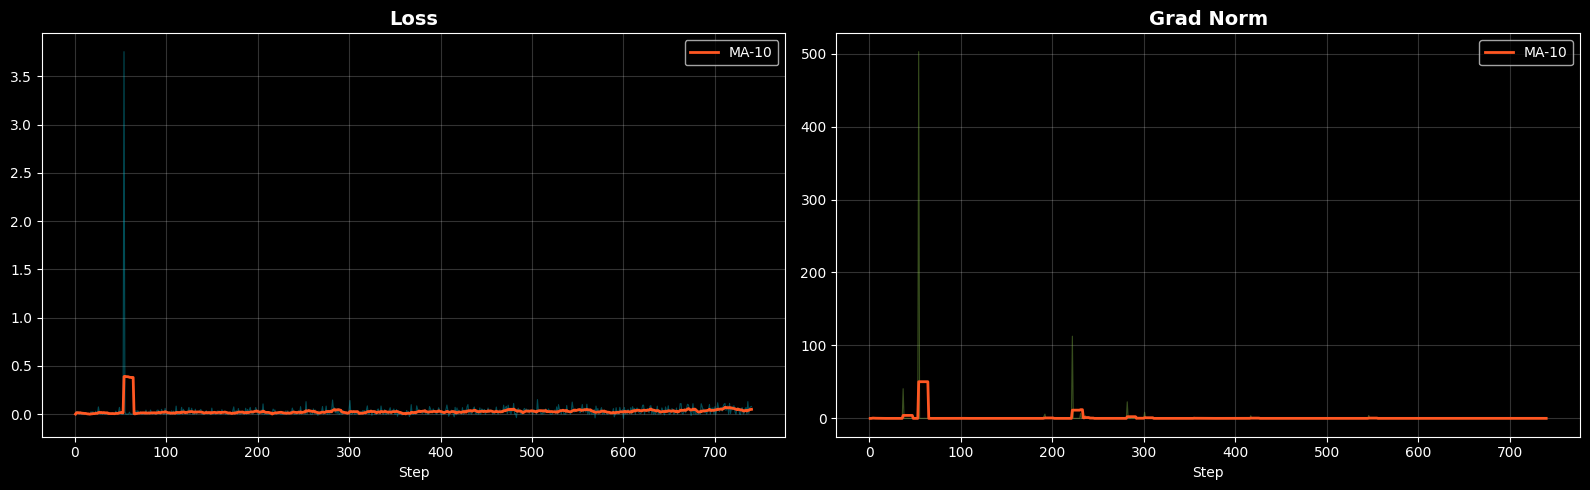

In [11]:
# Фильтруем аномальные значения loss и grad_norm
mask_normal = (df['loss'].abs() < 1e3) & (df['grad_norm'] < 1e3)
df_clean = df[mask_normal].copy()
print(f'Отфильтровано {len(df) - len(df_clean)} аномальных строк из {len(df)}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(df_clean['step'], df_clean['loss'], alpha=0.4, color='#00bcd4', linewidth=0.8)
# Скользящее среднее
window = 10
axes[0].plot(df_clean['step'], df_clean['loss'].rolling(window, min_periods=1).mean(), 
             color='#ff5722', linewidth=2, label=f'MA-{window}')
axes[0].set_title('Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Step')
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].plot(df_clean['step'], df_clean['grad_norm'], alpha=0.4, color='#8bc34a', linewidth=0.8)
axes[1].plot(df_clean['step'], df_clean['grad_norm'].rolling(window, min_periods=1).mean(), 
             color='#ff5722', linewidth=2, label=f'MA-{window}')
axes[1].set_title('Grad Norm', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Step')
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 2. Reward метрики

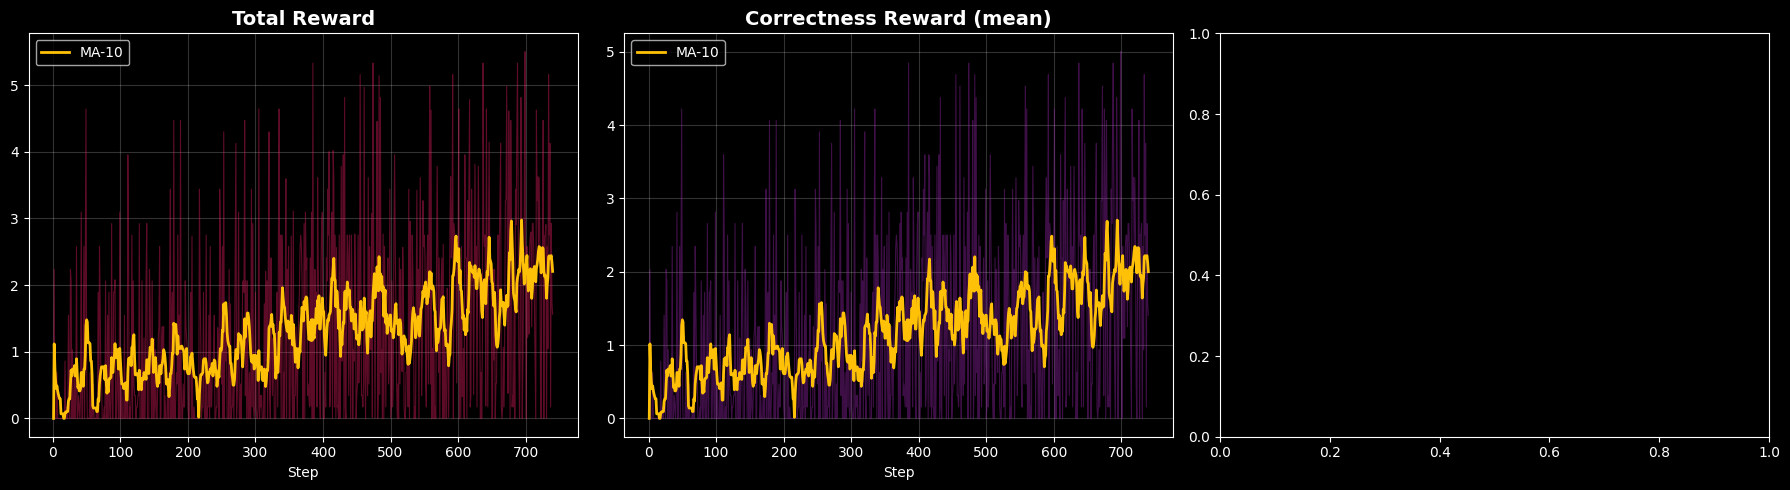

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Reward mean
axes[0].plot(df['step'], df['reward'], alpha=0.4, color='#e91e63', linewidth=0.8)
axes[0].plot(df['step'], df['reward'].rolling(window, min_periods=1).mean(), 
             color='#ffc107', linewidth=2, label=f'MA-{window}')
axes[0].set_title('Total Reward', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Step')
axes[0].legend()
axes[0].grid(alpha=0.2)

# Correctness reward
axes[1].plot(df['step'], df['rewards/correctness_reward_func/mean'], alpha=0.4, color='#9c27b0', linewidth=0.8)
axes[1].plot(df['step'], df['rewards/correctness_reward_func/mean'].rolling(window, min_periods=1).mean(), 
             color='#ffc107', linewidth=2, label=f'MA-{window}')
axes[1].set_title('Correctness Reward (mean)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Step')
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 3. Completions — длины генераций

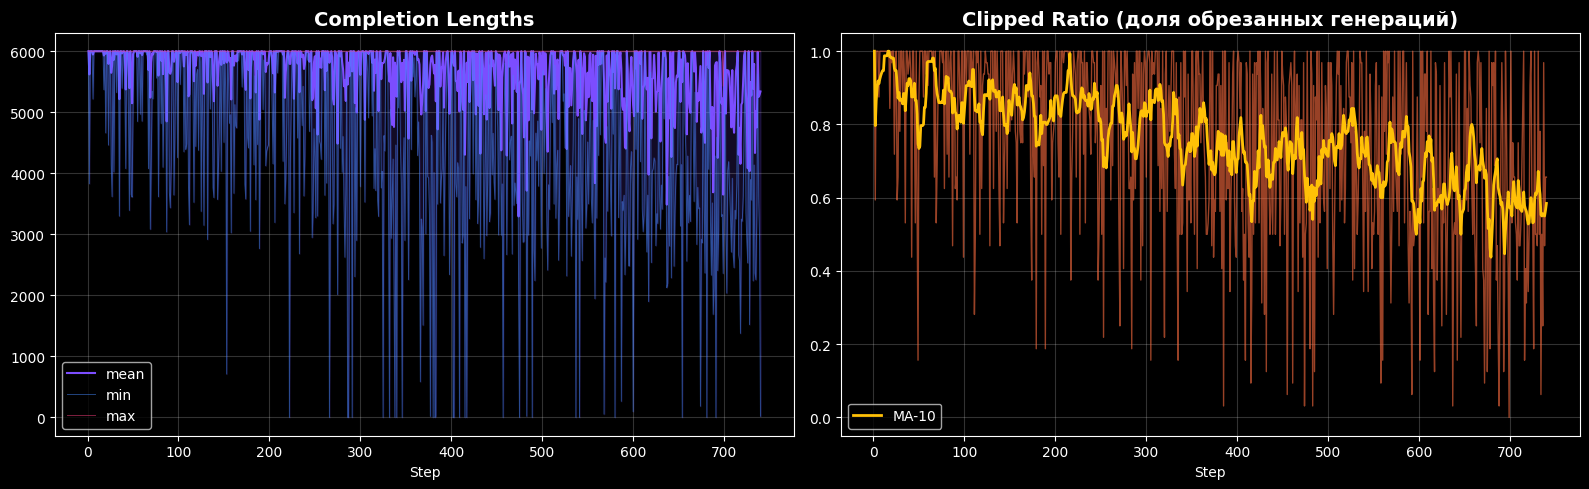

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].fill_between(df['step'], df['completions/min_length'], df['completions/max_length'], 
                      alpha=0.15, color='#7c4dff')
axes[0].plot(df['step'], df['completions/mean_length'], color='#7c4dff', linewidth=1.5, label='mean')
axes[0].plot(df['step'], df['completions/min_length'], color='#448aff', linewidth=0.7, alpha=0.5, label='min')
axes[0].plot(df['step'], df['completions/max_length'], color='#ff4081', linewidth=0.7, alpha=0.5, label='max')
axes[0].set_title('Completion Lengths', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Step')
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].plot(df['step'], df['completions/clipped_ratio'], color='#ff6e40', linewidth=1, alpha=0.6)
axes[1].plot(df['step'], df['completions/clipped_ratio'].rolling(window, min_periods=1).mean(), 
             color='#ffc107', linewidth=2, label=f'MA-{window}')
axes[1].set_title('Clipped Ratio (доля обрезанных генераций)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Step')
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 4. KL-дивергенция

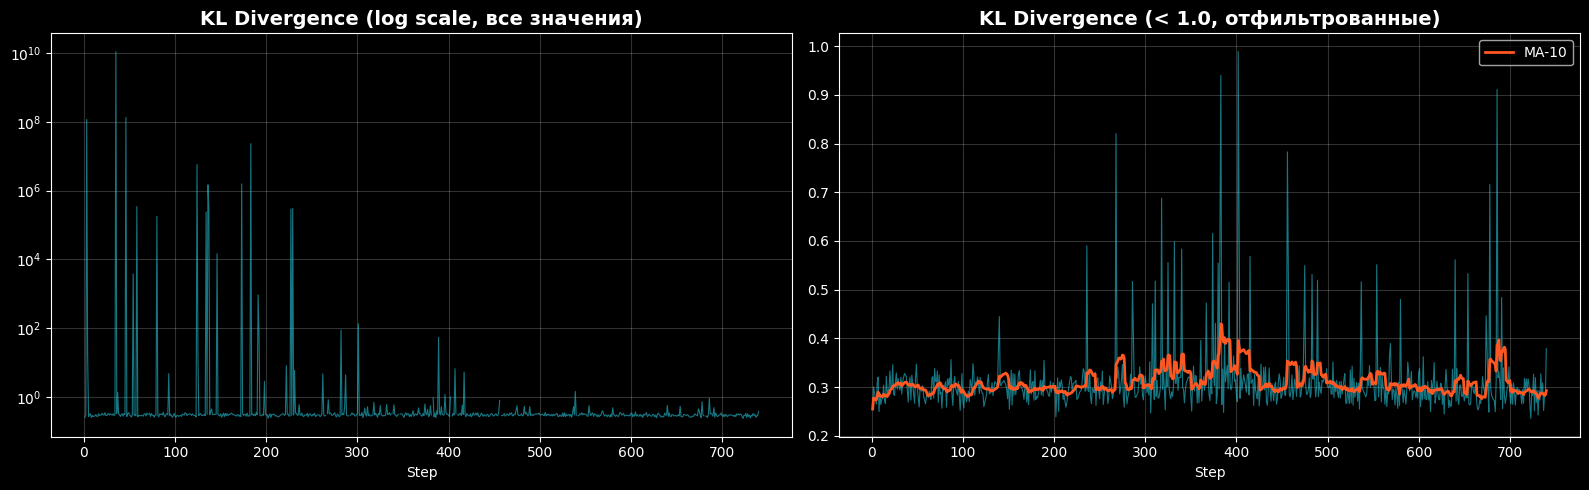

In [14]:
# KL может иметь выбросы, фильтруем
kl_series = df['kl'].copy()
kl_threshold = kl_series.quantile(0.95)  # верхний 95-й перцентиль для нормальных значений
kl_clean = kl_series.where(kl_series < kl_threshold * 10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Все значения (логарифмическая шкала)
axes[0].semilogy(df['step'], kl_series.clip(lower=1e-10), color='#26c6da', linewidth=0.8, alpha=0.6)
axes[0].set_title('KL Divergence (log scale, все значения)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Step')
axes[0].grid(alpha=0.2)

# Только нормальные значения
mask_kl = kl_series < 1.0
axes[1].plot(df['step'][mask_kl], kl_series[mask_kl], color='#26c6da', linewidth=0.8, alpha=0.6)
axes[1].plot(df['step'][mask_kl], kl_series[mask_kl].rolling(window, min_periods=1).mean(), 
             color='#ff5722', linewidth=2, label=f'MA-{window}')
axes[1].set_title('KL Divergence (< 1.0, отфильтрованные)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Step')
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 5. Learning Rate

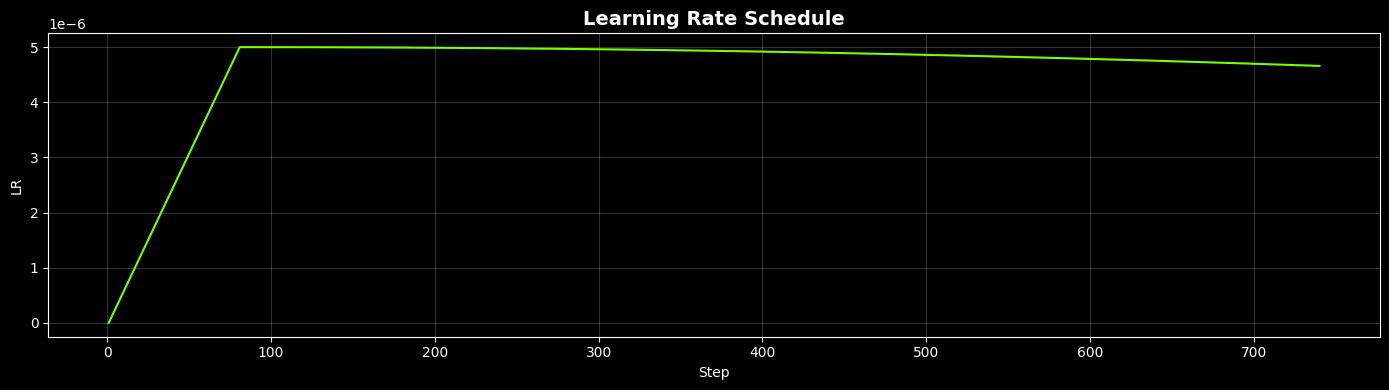

In [15]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['step'], df['learning_rate'], color='#76ff03', linewidth=1.5)
ax.set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
ax.set_xlabel('Step')
ax.set_ylabel('LR')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 6. Reward Std и Frac Reward Zero Std

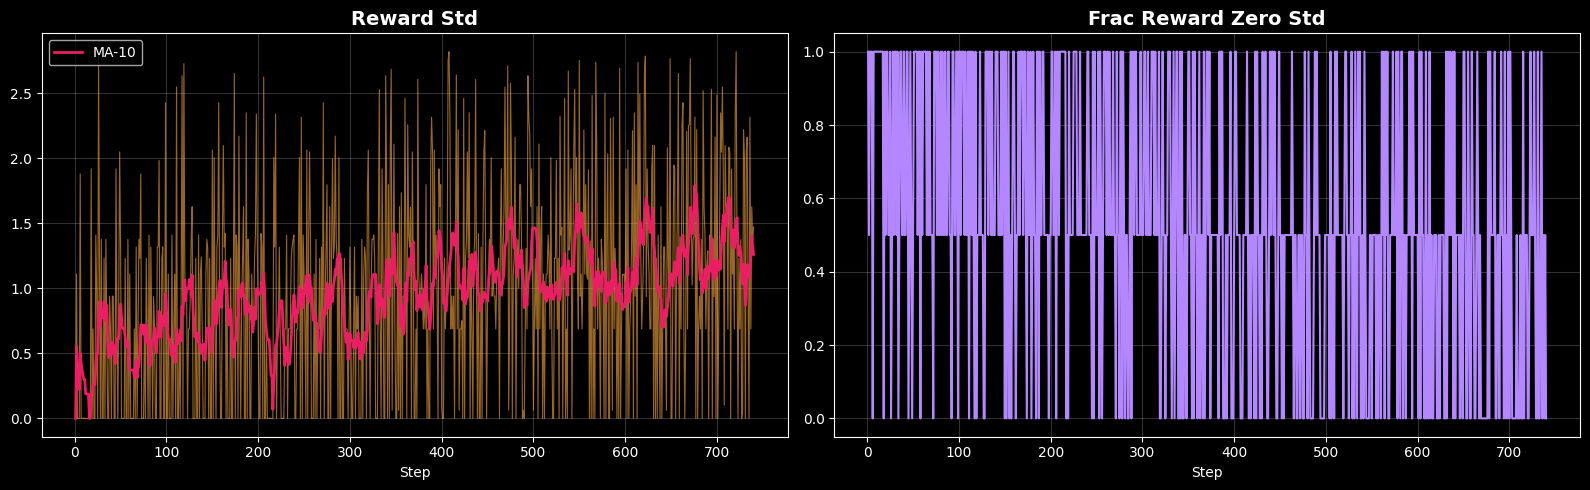

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(df['step'], df['reward_std'], color='#ffab40', linewidth=0.8, alpha=0.6)
axes[0].plot(df['step'], df['reward_std'].rolling(window, min_periods=1).mean(), 
             color='#e91e63', linewidth=2, label=f'MA-{window}')
axes[0].set_title('Reward Std', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Step')
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].plot(df['step'], df['frac_reward_zero_std'], color='#b388ff', linewidth=1.5)
axes[1].set_title('Frac Reward Zero Std', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Step')
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 7. Сводка по ключевым метрикам

In [17]:
# Берём последние 20 шагов для средних
last_n = 20
tail = df.tail(last_n)
tail_clean = df_clean.tail(last_n)

summary = {
    'Total steps': len(df),
    'Аномальных строк (loss > 1e3)': len(df) - len(df_clean),
    f'Avg Loss (last {last_n}, clean)': f"{tail_clean['loss'].mean():.4f}",
    f'Avg Reward (last {last_n})': f"{tail['reward'].mean():.4f}",
    f'Avg Correctness Reward (last {last_n})': f"{tail['rewards/correctness_reward_func/mean'].mean():.4f}",
    f'Avg Completion Length (last {last_n})': f"{tail['completions/mean_length'].mean():.0f}",
    f'Avg Clipped Ratio (last {last_n})': f"{tail['completions/clipped_ratio'].mean():.4f}",
    f'Avg KL (last {last_n})': f"{tail['kl'].mean():.6f}",
    f'Max LR': f"{df['learning_rate'].max():.2e}",
}

for k, v in summary.items():
    print(f'{k:>45s}: {v}')

                                  Total steps: 740
                Аномальных строк (loss > 1e3): 16
                    Avg Loss (last 20, clean): 0.0456
                         Avg Reward (last 20): 2.1406
             Avg Correctness Reward (last 20): 1.9453
              Avg Completion Length (last 20): 5286
                  Avg Clipped Ratio (last 20): 0.6031
                             Avg KL (last 20): 0.288012
                                       Max LR: 5.00e-06
